# Phase A — Dataset Audit & Scaffold Split
Run every cell in order. Do NOT skip any cell. Each section has a **RESULT** print at the end — paste those results if you hit an error downstream.

## A0 — Imports & Config

In [1]:
import pandas as pd
import numpy as np
import selfies as sf
import wandb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from tqdm.auto import tqdm
from collections import defaultdict, Counter
from dataclasses import dataclass
from typing import Optional
import json, random, warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, DataStructs, Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  # suppress RDKit noise

# ── CONFIG ────────────────────────────────────────────────────────────────────
@dataclass
class AuditConfig:
    raw_dir: Path = Path(r'D:\AU - Ahmedabad Uni\sem2\DL\DL projec\multimodal_spectroscopic_dataset\multimodal_spectroscopic_dataset')
    out_dir: Path = Path('audit_outputs')          # all outputs saved here
    tanimoto_sample_n: int = 5000                  # molecules to sample for diversity check
    random_seed: int = 42
    train_frac: float = 0.90
    val_frac:   float = 0.05
    test_frac:  float = 0.05
    wandb_project: str = 'spectro-elucidation'

CFG = AuditConfig()
CFG.out_dir.mkdir(exist_ok=True)
random.seed(CFG.random_seed)
np.random.seed(CFG.random_seed)
print('Config OK')
print(f'Output dir: {CFG.out_dir.resolve()}')

Config OK
Output dir: D:\AU - Ahmedabad Uni\sem2\DL\DL projec\multimodal_spectroscopic_dataset\audit_outputs


## A1 — Load All Chunks
Loads all 245 parquet files into one DataFrame. ~16GB RAM used during load; released once we drop heavy array columns.

In [2]:
files = sorted(CFG.raw_dir.rglob('aligned_chunk_*.parquet'))
print(f'Found {len(files)} chunk files')
assert len(files) == 245, f'Expected 245 files, got {len(files)}'

# Columns needed for the full audit.
# Dense spectrum arrays (ir_spectra, h_nmr_spectra, c_nmr_spectra, hsqc_nmr_spectrum)
# are each 1800- or 10000-point float arrays. Loading all 245 chunks simultaneously
# exceeds 16GB RAM. Shape and zero-IR checks in A7/A8 load ONE chunk at a time.
LIGHT_COLS = [
    'smiles',
    'molecular_formula',
    'h_nmr_peaks',
    'c_nmr_peaks',
    'hsqc_nmr_peaks',
    'msms_positive_10ev',
    'msms_positive_20ev',
    'msms_positive_40ev',
    'msms_negative_10ev',
    'msms_negative_20ev',
    'msms_negative_40ev',
    'msms_fragments_positive',
    'msms_fragments_negative',
]

# Dense spectrum columns — loaded one chunk at a time in A7/A8 only
DENSE_COLS = ['ir_spectra', 'h_nmr_spectra', 'c_nmr_spectra', 'hsqc_nmr_spectrum']

df_peek = pd.read_parquet(files[0], engine='pyarrow', columns=LIGHT_COLS)
print(f'Loading columns: {LIGHT_COLS}')
print(f'Skipping (dense, per-chunk in A7/A8): {DENSE_COLS}')
print(f'Rows per chunk (first): {len(df_peek)}')
del df_peek

chunks = []
for f in tqdm(files, desc='Loading chunks (light cols only)'):
    df_chunk = pd.read_parquet(f, engine='pyarrow', columns=LIGHT_COLS)
    chunks.append(df_chunk)

df_full = pd.concat(chunks, ignore_index=True)
del chunks

import gc; gc.collect()

print(f'Full dataset shape: {df_full.shape}')
print(f'Memory usage: {df_full.memory_usage(deep=True).sum() / 1e9:.2f} GB')
print(f'Columns loaded: {df_full.columns.tolist()}')


Found 245 chunk files
Loading columns: ['smiles', 'molecular_formula', 'h_nmr_peaks', 'c_nmr_peaks', 'hsqc_nmr_peaks', 'msms_positive_10ev', 'msms_positive_20ev', 'msms_positive_40ev', 'msms_negative_10ev', 'msms_negative_20ev', 'msms_negative_40ev', 'msms_fragments_positive', 'msms_fragments_negative']
Skipping (dense, per-chunk in A7/A8): ['ir_spectra', 'h_nmr_spectra', 'c_nmr_spectra', 'hsqc_nmr_spectrum']
Rows per chunk (first): 3235


Loading chunks (light cols only):   0%|          | 0/245 [00:00<?, ?it/s]

Full dataset shape: (794403, 13)
Memory usage: 1.17 GB
Columns loaded: ['smiles', 'molecular_formula', 'h_nmr_peaks', 'c_nmr_peaks', 'hsqc_nmr_peaks', 'msms_positive_10ev', 'msms_positive_20ev', 'msms_positive_40ev', 'msms_negative_10ev', 'msms_negative_20ev', 'msms_negative_40ev', 'msms_fragments_positive', 'msms_fragments_negative']


## A2 — Null / Empty Check (All Modalities)

In [4]:
def count_empty(series: pd.Series) -> int:
    """Count None, NaN, empty arrays, and zero-length lists."""
    empty = 0
    for val in series:
        if val is None:
            empty += 1
        elif isinstance(val, float) and np.isnan(val):
            empty += 1
        elif isinstance(val, np.ndarray) and val.size == 0:
            empty += 1
        elif isinstance(val, (list, tuple)) and len(val) == 0:
            empty += 1
    return empty

def count_nan_arrays(series: pd.Series) -> int:
    """Count arrays that contain any NaN value (numeric arrays only)."""
    bad = 0
    for val in series:
        if not isinstance(val, np.ndarray) or val.size == 0:
            continue
        # Skip object arrays (MS/MS fragment dicts, peak string arrays, etc.)
        if val.dtype == object:
            continue
        try:
            if np.isnan(val).any():
                bad += 1
        except (TypeError, ValueError):
            continue
    return bad

n_total = len(df_full)
print(f'Total molecules: {n_total:,}\n')

null_report = {}
for col in df_full.columns:
    n_empty   = count_empty(df_full[col])
    n_nan_arr = count_nan_arrays(df_full[col]) if col != 'smiles' else 0
    null_report[col] = {'empty': n_empty, 'nan_in_array': n_nan_arr}
    pct = n_empty / n_total * 100
    flag = ' ← PROBLEM' if n_empty > 0 else ''
    print(f'{col:<35} empty={n_empty:>6} ({pct:.2f}%)  nan_in_arr={n_nan_arr}{flag}')

with open(CFG.out_dir / 'null_report.json', 'w') as f:
    json.dump(null_report, f, indent=2)
print('\n[SAVED] null_report.json')

Total molecules: 794,403

smiles                              empty=     0 (0.00%)  nan_in_arr=0
molecular_formula                   empty=     0 (0.00%)  nan_in_arr=0
h_nmr_peaks                         empty=     0 (0.00%)  nan_in_arr=0
c_nmr_peaks                         empty=     0 (0.00%)  nan_in_arr=0
hsqc_nmr_peaks                      empty=    24 (0.00%)  nan_in_arr=0 ← PROBLEM
msms_positive_10ev                  empty=     0 (0.00%)  nan_in_arr=0
msms_positive_20ev                  empty=     0 (0.00%)  nan_in_arr=0
msms_positive_40ev                  empty=     0 (0.00%)  nan_in_arr=0
msms_negative_10ev                  empty=     0 (0.00%)  nan_in_arr=0
msms_negative_20ev                  empty=     0 (0.00%)  nan_in_arr=0
msms_negative_40ev                  empty=     0 (0.00%)  nan_in_arr=0
msms_fragments_positive             empty=     0 (0.00%)  nan_in_arr=0
msms_fragments_negative             empty=     0 (0.00%)  nan_in_arr=0

[SAVED] null_report.json


## A3 — SMILES Canonicalization & Duplicate Detection

In [5]:
def canonicalize(smi: str) -> Optional[str]:
    """Return canonical SMILES or None if RDKit cannot parse."""
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol else None
    except Exception:
        return None

print('Canonicalizing SMILES (this takes ~5-10 min for 790k molecules)...')
tqdm.pandas(desc='Canonicalizing')
df_full['canonical_smiles'] = df_full['smiles'].progress_apply(canonicalize)

n_invalid = df_full['canonical_smiles'].isna().sum()
n_valid   = n_total - n_invalid
print(f'\nValid SMILES:   {n_valid:,} ({n_valid/n_total*100:.3f}%)')
print(f'Invalid SMILES: {n_invalid:,} ({n_invalid/n_total*100:.3f}%)')

# Drop unparseable rows — they cannot be used for training
df_valid = df_full.dropna(subset=['canonical_smiles']).reset_index(drop=True)
print(f'Dataset after dropping invalid: {len(df_valid):,}')

# Duplicate detection
n_dupes = df_valid['canonical_smiles'].duplicated().sum()
print(f'Duplicate canonical SMILES: {n_dupes:,}')
if n_dupes > 0:
    print('  → Will deduplicate (keep first occurrence)')
    df_valid = df_valid.drop_duplicates(subset='canonical_smiles', keep='first').reset_index(drop=True)
    print(f'  → After deduplication: {len(df_valid):,}')

print(f'\n[RESULT] Clean, deduplicated dataset: {len(df_valid):,} molecules')

Canonicalizing SMILES (this takes ~5-10 min for 790k molecules)...


Canonicalizing:   0%|          | 0/794403 [00:00<?, ?it/s]


Valid SMILES:   794,403 (100.000%)
Invalid SMILES: 0 (0.000%)
Dataset after dropping invalid: 794,403
Duplicate canonical SMILES: 5,131
  → Will deduplicate (keep first occurrence)
  → After deduplication: 789,272

[RESULT] Clean, deduplicated dataset: 789,272 molecules


## A4 — SELFIES Round-Trip Validation
Every SMILES must survive: SMILES → SELFIES → SMILES (canonical) round-trip. Failures mean that SELFIES cannot represent this molecule — we must exclude them.

In [6]:
def selfies_roundtrip(smi: str) -> Optional[str]:
    """Return SELFIES string if round-trip is clean, else None."""
    try:
        enc = sf.encoder(smi)
        if enc is None:
            return None
        dec_smi = sf.decoder(enc)
        if dec_smi is None:
            return None
        # Round-trip check: decoded SMILES must re-canonicalize to original
        dec_canonical = canonicalize(dec_smi)
        if dec_canonical != smi:  # smi is already canonical here
            return None
        return enc
    except Exception:
        return None

print('Validating SELFIES round-trips...')
df_valid['selfies'] = df_valid['canonical_smiles'].progress_apply(selfies_roundtrip)

n_selfies_fail = df_valid['selfies'].isna().sum()
n_selfies_ok   = len(df_valid) - n_selfies_fail
rt_pct = n_selfies_ok / len(df_valid) * 100
print(f'\nSELFIES round-trip OK:   {n_selfies_ok:,} ({rt_pct:.3f}%)')
print(f'SELFIES round-trip FAIL: {n_selfies_fail:,}')

# Show some failures for debugging
failures = df_valid[df_valid['selfies'].isna()]['canonical_smiles'].head(10).tolist()
if failures:
    print('\nSample round-trip failures (first 10):')
    for s in failures:
        print(f'  {s}')

assert rt_pct >= 99.0, f'Round-trip rate {rt_pct:.2f}% is below 99% — check selfies library version'

df_valid = df_valid.dropna(subset=['selfies']).reset_index(drop=True)
print(f'\n[RESULT] Final clean dataset after SELFIES filter: {len(df_valid):,} molecules')

Validating SELFIES round-trips...


Canonicalizing:   0%|          | 0/789272 [00:00<?, ?it/s]


SELFIES round-trip OK:   789,272 (100.000%)
SELFIES round-trip FAIL: 0

[RESULT] Final clean dataset after SELFIES filter: 789,272 molecules


## A5 — SMILES & SELFIES Length Distributions
The 99th percentile determines the decoder's max sequence length.

SMILES char length:
  mean=39.4  median=39  p95=61  p99=71  p99.9=88  max=127
SELFIES token count:
  mean=36.4  median=36  p95=57  p99=62  p99.9=66  max=75

[RESULT] Recommended max_decoder_seq_len = 82  (p99=62 + 20 buffer)


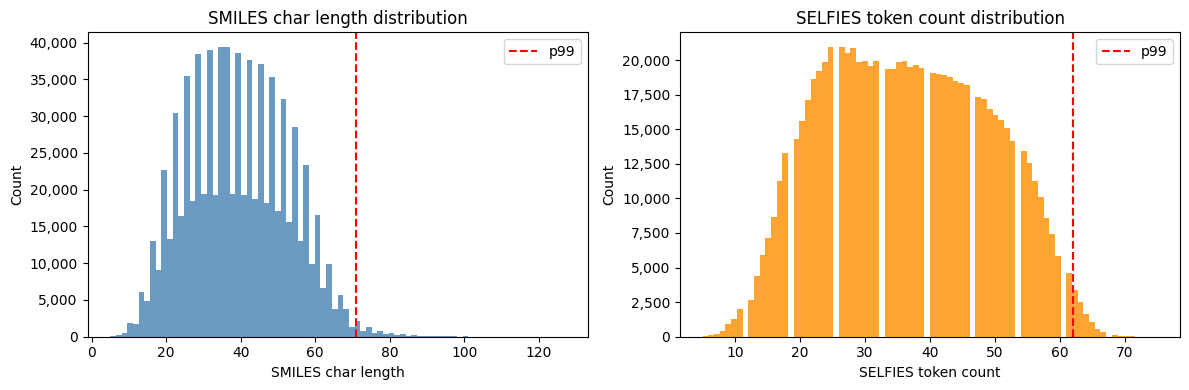

[SAVED] length_distributions.png


In [7]:
df_valid['smiles_len']  = df_valid['canonical_smiles'].str.len()
# SELFIES length = number of tokens (each token is [...])
df_valid['selfies_len'] = df_valid['selfies'].apply(lambda s: len(list(sf.split_selfies(s))))

for col, label in [('smiles_len', 'SMILES char length'), ('selfies_len', 'SELFIES token count')]:
    arr = df_valid[col]
    p50, p95, p99, p999 = np.percentile(arr, [50, 95, 99, 99.9])
    print(f'{label}:')
    print(f'  mean={arr.mean():.1f}  median={p50:.0f}  p95={p95:.0f}  p99={p99:.0f}  p99.9={p999:.0f}  max={arr.max()}')

p99_selfies = int(np.percentile(df_valid['selfies_len'], 99))
max_decoder_len = p99_selfies + 20
print(f'\n[RESULT] Recommended max_decoder_seq_len = {max_decoder_len}  (p99={p99_selfies} + 20 buffer)')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label, color in zip(
    axes,
    ['smiles_len', 'selfies_len'],
    ['SMILES char length', 'SELFIES token count'],
    ['steelblue', 'darkorange']
):
    ax.hist(df_valid[col], bins=80, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(np.percentile(df_valid[col], 99), color='red', lw=1.5, linestyle='--', label='p99')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label + ' distribution')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(CFG.out_dir / 'length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] length_distributions.png')

## A6 — Heavy Atom Count Distribution
Should match Figure 2A of the paper (peak around 15-20 heavy atoms).

Computing heavy atom counts...


Canonicalizing:   0%|          | 0/789272 [00:00<?, ?it/s]

Heavy atom count stats: min=5  mean=22.4  median=22  max=35
Outside paper range [5,35]: 0


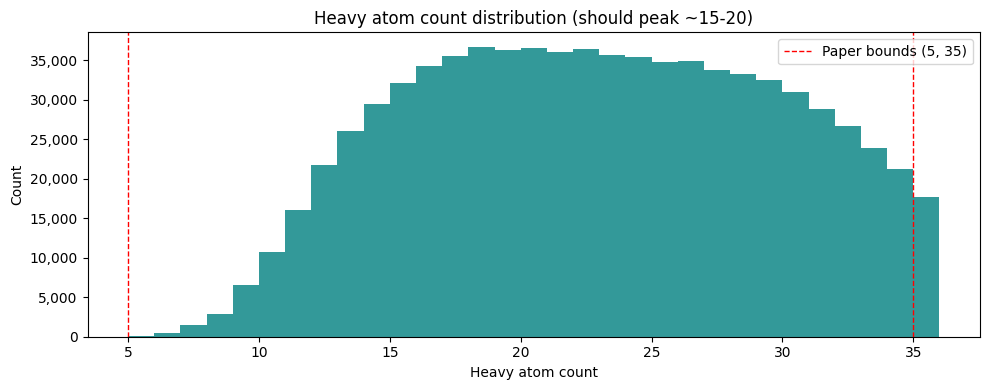

[SAVED] heavy_atom_distribution.png


In [8]:
def heavy_atom_count(smi: str) -> Optional[int]:
    mol = Chem.MolFromSmiles(smi)
    return mol.GetNumHeavyAtoms() if mol else None

print('Computing heavy atom counts...')
df_valid['n_heavy'] = df_valid['canonical_smiles'].progress_apply(heavy_atom_count)

hac = df_valid['n_heavy'].dropna()
print(f'Heavy atom count stats: min={hac.min():.0f}  mean={hac.mean():.1f}  median={hac.median():.0f}  max={hac.max():.0f}')
print(f'Outside paper range [5,35]: {((hac < 5) | (hac > 35)).sum():,}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hac, bins=range(int(hac.min()), int(hac.max())+2), color='teal', alpha=0.8, edgecolor='none')
ax.axvline(5,  color='red', lw=1, linestyle='--', label='Paper bounds (5, 35)')
ax.axvline(35, color='red', lw=1, linestyle='--')
ax.set_xlabel('Heavy atom count')
ax.set_ylabel('Count')
ax.set_title('Heavy atom count distribution (should peak ~15-20)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(CFG.out_dir / 'heavy_atom_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] heavy_atom_distribution.png')

## A7 — Spectral Array Shape Validation

In [11]:
# Expected shapes from the paper
EXPECTED_SHAPES = {
    'ir_spectra':     (1800,),
    'h_nmr_spectra':  (10000,),
    'c_nmr_spectra':  (10000,),
}

# Dense cols were not loaded into df_full — sample ONE chunk here for shape checks
df_dense_sample = pd.read_parquet(files[0], engine='pyarrow', columns=list(EXPECTED_SHAPES.keys()))
print(f'''Shape validation on chunk 0 ({len(df_dense_sample)} rows: ''')
shape_issues = {}

for col, expected in EXPECTED_SHAPES.items():
    shapes = []
    for val in df_dense_sample[col]:
        if isinstance(val, np.ndarray):
            shapes.append(val.shape)
    counter = Counter(shapes)
    dominant = counter.most_common(1)[0] if counter else (None, 0)
    match = 'OK' if dominant[0] == expected else 'MISMATCH'
    print(f'{col:<30} expected={expected}  dominant={dominant[0]}  {match}')
    if dominant[0] != expected:
        shape_issues[col] = {'expected': str(expected), 'found': str(dominant[0])}

# Variable-length columns — use df_full (already loaded)
VARIABLE_COLS = [
    'h_nmr_peaks', 'c_nmr_peaks', 'hsqc_nmr_peaks',
    'msms_positive_10ev', 'msms_negative_10ev'
]
print('Variable-length columns (peak lists, from full dataset):')
sample_idx = np.random.choice(len(df_valid), size=min(500, len(df_valid)), replace=False)
df_var_sample = df_valid.iloc[sample_idx]
for col in VARIABLE_COLS:
    if col not in df_valid.columns:
        print(f'  {col} not in df_valid (skipped)')
        continue
    lengths = []
    for val in df_var_sample[col]:
        if isinstance(val, np.ndarray):
            lengths.append(len(val))
        elif isinstance(val, (list, tuple)):
            lengths.append(len(val))
    if lengths:
        print(f'  {col:<35} len: min={min(lengths)}  mean={np.mean(lengths):.1f}  max={max(lengths)}')

del df_dense_sample
import gc; gc.collect()

if shape_issues:
    print(f'Shape mismatches: {shape_issues}')
else:
    print('[RESULT] All fixed-length spectral arrays match expected shapes.')


Shape validation on chunk 0 (3235 rows: 
ir_spectra                     expected=(1800,)  dominant=(1800,)  OK
h_nmr_spectra                  expected=(10000,)  dominant=(10000,)  OK
c_nmr_spectra                  expected=(10000,)  dominant=(10000,)  OK
Variable-length columns (peak lists, from full dataset):
  h_nmr_peaks                         len: min=3  mean=9.3  max=21
  c_nmr_peaks                         len: min=4  mean=17.4  max=58
  hsqc_nmr_peaks                      len: min=1  mean=8.7  max=23
  msms_positive_10ev                  len: min=1  mean=3.8  max=31
  msms_negative_10ev                  len: min=1  mean=3.4  max=31
[RESULT] All fixed-length spectral arrays match expected shapes.


## A8 — IR Spectrum Zero-Intensity Check
An all-zero IR spectrum means the simulation failed. Count and drop these.

Checking for zero/degenerate IR spectra (streaming per chunk)...


IR zero-check:   0%|          | 0/245 [00:00<?, ?it/s]

Zero/degenerate IR spectra: 0 (0.000%)
All IR spectra are non-zero. OK


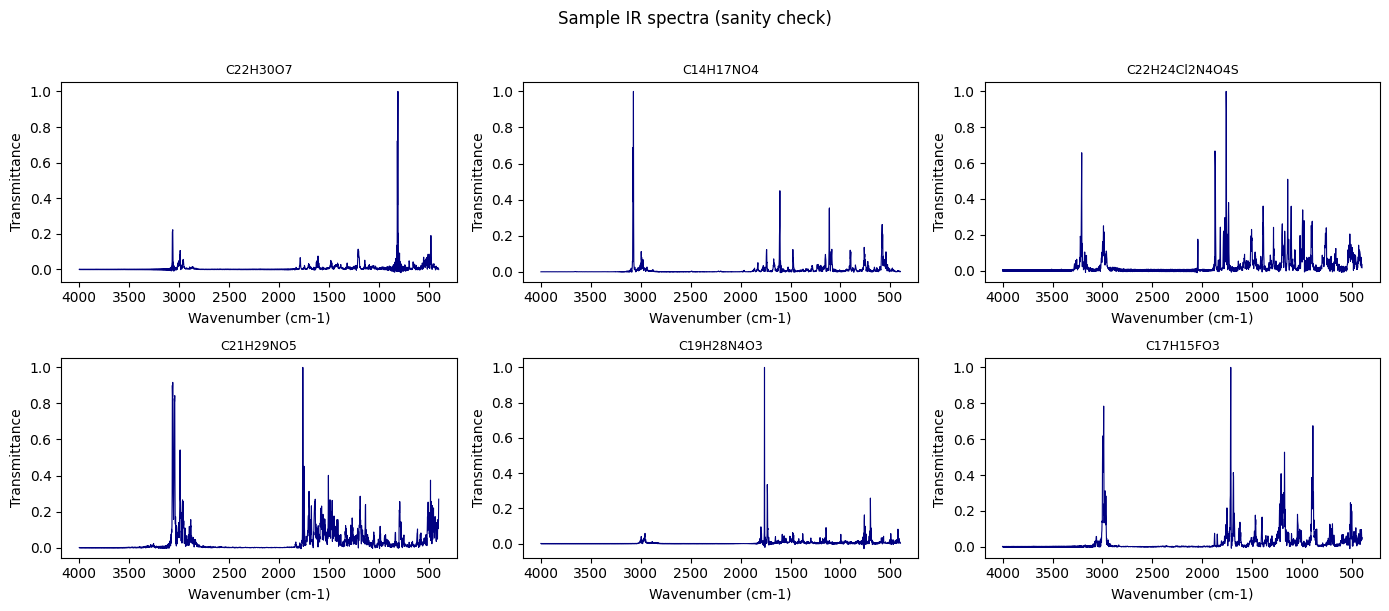

[SAVED] sample_ir_spectra.png


In [12]:
def is_zero_ir(arr) -> bool:
    if isinstance(arr, np.ndarray):
        return np.all(arr == 0) or np.all(np.isnan(arr.astype(float)))
    return True

# Stream through all chunks — only load ir_spectra column per chunk
# Match rows to df_valid using canonical_smiles as key (df_valid has no dense cols)
print('Checking for zero/degenerate IR spectra (streaming per chunk)...')

zero_ir_smiles = set()
chunk_offset = 0
for f in tqdm(files, desc='IR zero-check'):
    df_ir = pd.read_parquet(f, engine='pyarrow', columns=['smiles', 'ir_spectra'])
    for _, row in df_ir.iterrows():
        if is_zero_ir(row['ir_spectra']):
            zero_ir_smiles.add(row['smiles'])
    del df_ir

import gc; gc.collect()

# Drop from df_valid by matching raw smiles (before canonicalization changed the string)
# Use canonical_smiles column which was derived from raw smiles
n_zero_ir = df_valid['smiles'].isin(zero_ir_smiles).sum() if 'smiles' in df_valid.columns else 0
print(f'Zero/degenerate IR spectra: {n_zero_ir:,} ({n_zero_ir/len(df_valid)*100:.3f}%)')

if n_zero_ir > 0:
    df_valid = df_valid[~df_valid['smiles'].isin(zero_ir_smiles)].reset_index(drop=True)
    print(f'Dropped. Remaining: {len(df_valid):,}')
else:
    print('All IR spectra are non-zero. OK')

# Plot sample IR spectra — load from first chunk only
df_ir_plot = pd.read_parquet(files[0], engine='pyarrow', columns=['ir_spectra', 'molecular_formula'])
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
wavenumbers = np.linspace(400, 4000, 1800)
sample_plot_idx = np.random.choice(len(df_ir_plot), 6, replace=False)
for ax, idx in zip(axes.flat, sample_plot_idx):
    ir = df_ir_plot.iloc[idx]['ir_spectra']
    if isinstance(ir, np.ndarray) and ir.shape == (1800,):
        ax.plot(wavenumbers, ir, lw=0.8, color='navy')
        ax.invert_xaxis()
        ax.set_xlabel('Wavenumber (cm-1)')
        ax.set_ylabel('Transmittance')
        ax.set_title(df_ir_plot.iloc[idx]['molecular_formula'], fontsize=9)
del df_ir_plot; gc.collect()
plt.suptitle('Sample IR spectra (sanity check)', y=1.01)
plt.tight_layout()
plt.savefig(CFG.out_dir / 'sample_ir_spectra.png', dpi=120, bbox_inches='tight')
plt.show()
print('[SAVED] sample_ir_spectra.png')


## A9 — Tanimoto Diversity Sampling
Samples 5,000 molecules, computes pairwise Tanimoto similarity, tells us how structurally diverse the dataset is.

Computing pairwise Tanimoto for 5000 sampled molecules...


Fingerprinting:   0%|          | 0/5000 [00:00<?, ?it/s]

Valid fingerprints: 5000


Pairwise Tanimoto:   0%|          | 0/5000 [00:00<?, ?it/s]


Pairwise Tanimoto stats:
  mean=0.116  median=0.113  p90=0.175  max=0.415
  Pairs > 0.85 similarity: 0 / 5000 (0.0%)


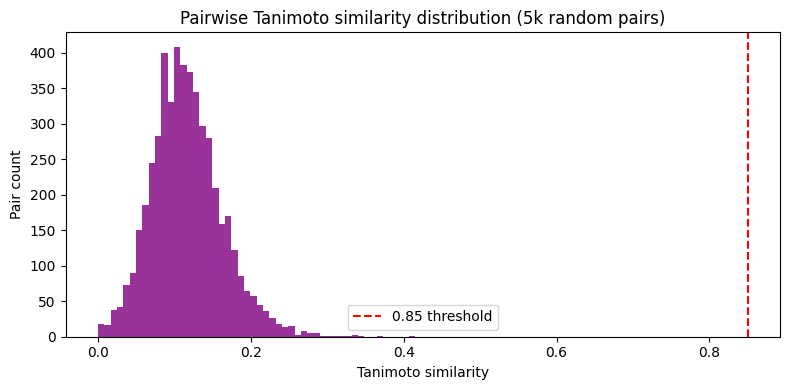

[SAVED] tanimoto_diversity.png

[RESULT] Dataset diversity — mean pairwise Tanimoto = 0.116 (lower = more diverse)


In [13]:
from rdkit.Chem import AllChem

print(f'Computing pairwise Tanimoto for {CFG.tanimoto_sample_n} sampled molecules...')
sample_smiles = df_valid['canonical_smiles'].sample(n=CFG.tanimoto_sample_n, random_state=CFG.random_seed)

fps = []
for smi in tqdm(sample_smiles, desc='Fingerprinting'):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
        fps.append(fp)

print(f'Valid fingerprints: {len(fps)}')

# Compute pairwise similarities on a random subset of 500 pairs (full 5000x5000 is too slow)
n_pairs = 5000
pair_sims = []
indices = list(range(len(fps)))
for _ in tqdm(range(n_pairs), desc='Pairwise Tanimoto'):
    i, j = random.sample(indices, 2)
    sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
    pair_sims.append(sim)

pair_sims = np.array(pair_sims)
print(f'\nPairwise Tanimoto stats:')
print(f'  mean={pair_sims.mean():.3f}  median={np.median(pair_sims):.3f}  p90={np.percentile(pair_sims,90):.3f}  max={pair_sims.max():.3f}')
print(f'  Pairs > 0.85 similarity: {(pair_sims > 0.85).sum()} / {n_pairs} ({(pair_sims > 0.85).mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pair_sims, bins=50, color='purple', alpha=0.8, edgecolor='none')
ax.axvline(0.85, color='red', lw=1.5, linestyle='--', label='0.85 threshold')
ax.set_xlabel('Tanimoto similarity')
ax.set_ylabel('Pair count')
ax.set_title('Pairwise Tanimoto similarity distribution (5k random pairs)')
ax.legend()
plt.tight_layout()
plt.savefig(CFG.out_dir / 'tanimoto_diversity.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] tanimoto_diversity.png')
print(f'\n[RESULT] Dataset diversity — mean pairwise Tanimoto = {pair_sims.mean():.3f} (lower = more diverse)')

## A10 — Functional Group Imbalance Check
Groups with < 1,000 examples will need special handling in training (oversampling or focal loss).

Computing functional group flags for 50,000 molecules...


FG detection:   0%|          | 0/50000 [00:00<?, ?it/s]


Functional Group Counts (extrapolated to full 789,272 molecules):
  nitro                     sample_count=     0  est_full=       0  (0.0%)  ← RARE (needs oversampling)
  boronic_acid              sample_count=     0  est_full=       0  (0.0%)  ← RARE (needs oversampling)
  phosphate                 sample_count=     2  est_full=      31  (0.0%)  ← RARE (needs oversampling)
  lactone                   sample_count=     8  est_full=     126  (0.0%)  ← RARE (needs oversampling)
  anhydride                 sample_count=    39  est_full=     615  (0.1%)  ← RARE (needs oversampling)
  lactam                    sample_count=    92  est_full=   1,452  (0.2%)
  thiol                     sample_count=   183  est_full=   2,888  (0.4%)
  epoxide                   sample_count=   210  est_full=   3,314  (0.4%)
  acyl_chloride             sample_count=   216  est_full=   3,409  (0.4%)
  enamine                   sample_count=   724  est_full=  11,428  (1.4%)
  halide_I                  sample_cou

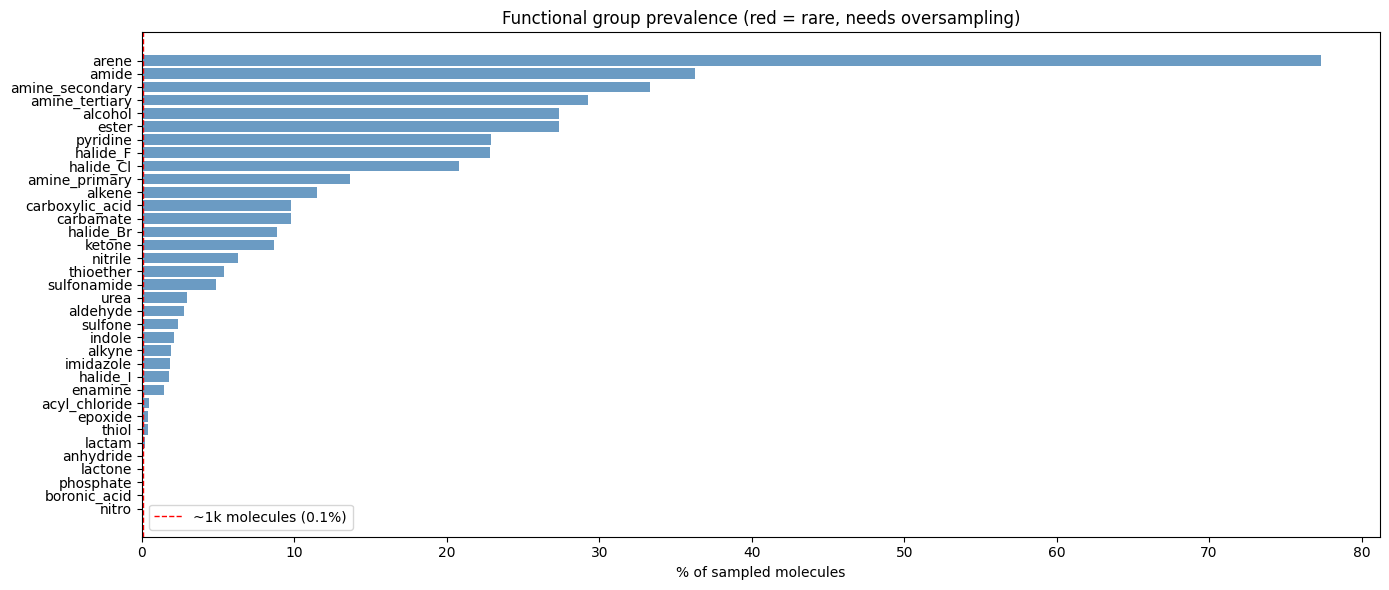

[SAVED] functional_group_imbalance.png

[RESULT] Rare functional groups (< 1k estimated): ['nitro', 'boronic_acid', 'phosphate', 'lactone', 'anhydride']


In [14]:
from rdkit.Chem import MolFromSmarts

# 35 SMARTS-defined functional groups from the paper's benchmark
FUNCTIONAL_GROUPS = {
    'alcohol':           '[OX2H]',
    'aldehyde':          '[CX3H1](=O)',
    'ketone':            '[CX3](=O)([#6])[#6]',
    'carboxylic_acid':   '[CX3](=O)[OX2H1]',
    'ester':             '[CX3](=O)[OX2][#6]',
    'amide':             '[CX3](=O)[NX3]',
    'amine_primary':     '[NX3H2][#6]',
    'amine_secondary':   '[NX3H1]([#6])[#6]',
    'amine_tertiary':    '[NX3]([#6])([#6])[#6]',
    'nitrile':           '[CX2]#N',
    'nitro':             '[NX3](=O)=O',
    'thiol':             '[SX2H]',
    'thioether':         '[SX2]([#6])[#6]',
    'sulfonamide':       '[SX4](=O)(=O)[NX3]',
    'sulfone':           '[SX4](=O)(=O)([#6])[#6]',
    'phosphate':         '[PX4](=O)([OX2])[OX2][OX2]',
    'halide_F':          '[F]',
    'halide_Cl':         '[Cl]',
    'halide_Br':         '[Br]',
    'halide_I':          '[I]',
    'alkene':            '[CX3]=[CX3]',
    'alkyne':            '[CX2]#[CX2]',
    'arene':             'c1ccccc1',
    'pyridine':          'n1ccccc1',
    'imidazole':         'c1cnc[nH]1',
    'indole':            'c1ccc2[nH]ccc2c1',
    'anhydride':         '[CX3](=O)O[CX3]=O',
    'acyl_chloride':     '[CX3](=O)[Cl]',
    'epoxide':           '[C]1[O][C]1',
    'lactam':            'O=C1[N]CC1',
    'lactone':           'O=C1[O]CC1',
    'urea':              '[NX3][CX3](=O)[NX3]',
    'carbamate':         '[NX3][CX3](=O)[OX2]',
    'enamine':           '[NX3][CX3]=[CX3]',
    'boronic_acid':      '[B]([OX2H])[OX2H]',
}

SMARTS_PATTERNS = {name: MolFromSmarts(smarts) for name, smarts in FUNCTIONAL_GROUPS.items()}

def get_fg_flags(smi: str) -> dict:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return {name: 0 for name in FUNCTIONAL_GROUPS}
    return {name: int(mol.HasSubstructMatch(pat)) for name, pat in SMARTS_PATTERNS.items()}

# Sub-sample 50k for speed (accurate enough for imbalance check)
n_fg_sample = min(50_000, len(df_valid))
df_fg = df_valid['canonical_smiles'].sample(n=n_fg_sample, random_state=CFG.random_seed)
print(f'Computing functional group flags for {n_fg_sample:,} molecules...')

fg_counts = defaultdict(int)
for smi in tqdm(df_fg, desc='FG detection'):
    flags = get_fg_flags(smi)
    for name, present in flags.items():
        fg_counts[name] += present

# Scale counts to full dataset
scale = len(df_valid) / n_fg_sample
print(f'\nFunctional Group Counts (extrapolated to full {len(df_valid):,} molecules):')
rare_groups = []
sorted_fgs = sorted(fg_counts.items(), key=lambda x: x[1])
for name, count in sorted_fgs:
    est_full = int(count * scale)
    flag = '  ← RARE (needs oversampling)' if est_full < 1000 else ''
    if est_full < 1000:
        rare_groups.append(name)
    pct = count / n_fg_sample * 100
    print(f'  {name:<25} sample_count={count:>6}  est_full={est_full:>8,}  ({pct:.1f}%){flag}')

# Bar chart
fig, ax = plt.subplots(figsize=(14, 6))
names = [x[0] for x in sorted_fgs]
vals  = [x[1] / n_fg_sample * 100 for x in sorted_fgs]
colors = ['red' if n in rare_groups else 'steelblue' for n in names]
ax.barh(names, vals, color=colors, alpha=0.8)
ax.axvline(0.1, color='red', lw=1, linestyle='--', label='~1k molecules (0.1%)')
ax.set_xlabel('% of sampled molecules')
ax.set_title('Functional group prevalence (red = rare, needs oversampling)')
ax.legend()
plt.tight_layout()
plt.savefig(CFG.out_dir / 'functional_group_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] functional_group_imbalance.png')
print(f'\n[RESULT] Rare functional groups (< 1k estimated): {rare_groups}')

## A11 — Murcko Scaffold-Based Split
Implementation of Section 4.3 of the report. All molecules sharing a scaffold go exclusively to one split.

In [15]:
def get_murcko_scaffold(smi: str) -> Optional[str]:
    """Returns canonical SMILES of Murcko scaffold, or None if molecule has no rings."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    if scaffold is None or scaffold.GetNumAtoms() == 0:
        return '__ACYCLIC__'  # molecules with no ring system share this label
    return Chem.MolToSmiles(scaffold)

print('Computing Murcko scaffolds (this takes ~10 min)...')
df_valid['scaffold'] = df_valid['canonical_smiles'].progress_apply(get_murcko_scaffold)

scaffold_groups = df_valid.groupby('scaffold').indices  # scaffold_smiles → list of row indices
print(f'Unique scaffolds: {len(scaffold_groups):,}')
print(f'Acyclic molecules: {(df_valid["scaffold"] == "__ACYCLIC__").sum():,}')

# Sort scaffolds by group size (largest first)
scaffold_sizes = sorted(scaffold_groups.items(), key=lambda x: len(x[1]), reverse=True)
print(f'Largest scaffold: {scaffold_sizes[0][0][:60]}...  ({len(scaffold_sizes[0][1])} molecules)')

# Greedy scaffold split
train_idx, val_idx, test_idx = [], [], []
n = len(df_valid)
target_train = n * CFG.train_frac
target_val   = n * CFG.val_frac

for scaffold_smi, indices in tqdm(scaffold_sizes, desc='Splitting scaffolds'):
    idx_list = list(indices)
    if len(train_idx) < target_train:
        train_idx.extend(idx_list)
    elif len(val_idx) < target_val:
        val_idx.extend(idx_list)
    else:
        test_idx.extend(idx_list)

print(f'\nScaffold split result:')
print(f'  Train: {len(train_idx):,}  ({len(train_idx)/n*100:.2f}%)')
print(f'  Val:   {len(val_idx):,}  ({len(val_idx)/n*100:.2f}%)')
print(f'  Test:  {len(test_idx):,}  ({len(test_idx)/n*100:.2f}%)')
assert len(train_idx) + len(val_idx) + len(test_idx) == n, 'Split sizes do not sum to total!'

Computing Murcko scaffolds (this takes ~10 min)...


Canonicalizing:   0%|          | 0/789272 [00:00<?, ?it/s]

Unique scaffolds: 196,554
Acyclic molecules: 23,560
Largest scaffold: c1ccccc1...  (72314 molecules)


Splitting scaffolds:   0%|          | 0/196554 [00:00<?, ?it/s]


Scaffold split result:
  Train: 710,345  (90.00%)
  Val:   39,464  (5.00%)
  Test:  39,463  (5.00%)


## A12 — Verify Split Isolation (Max Cross-Split Tanimoto)

In [16]:
# Sample 200 test molecules and check max Tanimoto against 500 train molecules
# Full check is too slow; this is a representative audit
print('Verifying scaffold split isolation...')
test_sample  = random.sample(test_idx,  min(200, len(test_idx)))
train_sample = random.sample(train_idx, min(500, len(train_idx)))

def fp_from_smi(smi: str):
    mol = Chem.MolFromSmiles(smi)
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024) if mol else None

train_fps = [fp_from_smi(df_valid.iloc[i]['canonical_smiles']) for i in train_sample]
train_fps = [fp for fp in train_fps if fp is not None]

max_sims = []
for i in tqdm(test_sample, desc='Cross-split similarity'):
    test_fp = fp_from_smi(df_valid.iloc[i]['canonical_smiles'])
    if test_fp is None:
        continue
    sims = DataStructs.BulkTanimotoSimilarity(test_fp, train_fps)
    max_sims.append(max(sims))

max_sims = np.array(max_sims)
print(f'\nTest→Train max Tanimoto similarity:')
print(f'  mean={max_sims.mean():.3f}  median={np.median(max_sims):.3f}  max={max_sims.max():.3f}')
print(f'  Molecules with similarity > 0.85: {(max_sims > 0.85).sum()} / {len(max_sims)}')

if max_sims.max() > 0.85:
    print('⚠ Some test molecules have very similar training molecules — check scaffold assignment')
else:
    print('✓ Scaffold split looks clean — no test molecule closely resembles any training molecule')

print(f'\n[RESULT] Max cross-split Tanimoto = {max_sims.max():.3f}  (target: < 0.85)')

Verifying scaffold split isolation...


Cross-split similarity:   0%|          | 0/200 [00:00<?, ?it/s]


Test→Train max Tanimoto similarity:
  mean=0.276  median=0.265  max=0.600
  Molecules with similarity > 0.85: 0 / 200
✓ Scaffold split looks clean — no test molecule closely resembles any training molecule

[RESULT] Max cross-split Tanimoto = 0.600  (target: < 0.85)


## A13 — Save Split Index Files
Save train/val/test indices as parquet so training can load them without re-running the scaffold computation.

In [17]:
# Assign split labels and save the lightweight metadata dataframe
df_valid['split'] = 'train'
df_valid.loc[val_idx,  'split'] = 'val'
df_valid.loc[test_idx, 'split'] = 'test'

# Save lightweight metadata (SMILES, SELFIES, scaffold, split, derived stats)
meta_cols = ['canonical_smiles', 'selfies', 'molecular_formula', 'scaffold',
             'split', 'smiles_len', 'selfies_len', 'n_heavy']
df_meta = df_valid[meta_cols].copy()

meta_path = CFG.out_dir / 'dataset_metadata.parquet'
df_meta.to_parquet(meta_path, engine='pyarrow', index=True)
print(f'[SAVED] dataset_metadata.parquet  ({len(df_meta):,} rows, {meta_path.stat().st_size/1e6:.1f} MB)')

# Also save chunk-level original file paths + row positions for DataLoader
# This maps global index → (chunk_file, within_chunk_row_index)
print('Building chunk index map...')
chunk_sizes = []
for f in tqdm(files, desc='Reading chunk sizes'):
    chunk_sizes.append(pd.read_parquet(f, engine='pyarrow', columns=['smiles']).shape[0])

# cumulative offsets
offsets = np.cumsum([0] + chunk_sizes)
chunk_index = []
for global_idx in range(len(df_full)):  # df_full before cleaning
    chunk_num = np.searchsorted(offsets, global_idx, side='right') - 1
    within_chunk = global_idx - offsets[chunk_num]
    chunk_index.append((str(files[chunk_num]), int(within_chunk)))

# Align chunk_index to df_valid's original integer positions
# (df_valid still has original integer index from df_full)
df_meta['chunk_file']      = [chunk_index[i][0] for i in df_meta.index]
df_meta['chunk_row_idx']   = [chunk_index[i][1] for i in df_meta.index]

meta_path2 = CFG.out_dir / 'dataset_metadata_with_chunks.parquet'
df_meta.to_parquet(meta_path2, engine='pyarrow', index=True)
print(f'[SAVED] dataset_metadata_with_chunks.parquet  ({meta_path2.stat().st_size/1e6:.1f} MB)')

split_counts = df_meta['split'].value_counts()
print(f'\nFinal split counts:')
print(split_counts.to_string())

[SAVED] dataset_metadata.parquet  (789,272 rows, 78.4 MB)
Building chunk index map...


Reading chunk sizes:   0%|          | 0/245 [00:00<?, ?it/s]

[SAVED] dataset_metadata_with_chunks.parquet  (79.0 MB)

Final split counts:
split
train    710345
val       39464
test      39463


## A14 — SELFIES Vocabulary
Build the complete SELFIES token vocabulary from the training set. Needed for decoder embedding layer size.

In [18]:
train_selfies = df_meta[df_meta['split'] == 'train']['selfies']

vocab = set()
for sel in tqdm(train_selfies, desc='Building vocab'):
    for token in sf.split_selfies(sel):
        vocab.add(token)

# Add special tokens
special_tokens = ['[PAD]', '[BOS]', '[EOS]', '[UNK]']
all_tokens = special_tokens + sorted(vocab)

token2idx = {tok: i for i, tok in enumerate(all_tokens)}
idx2token = {i: tok for tok, i in token2idx.items()}

vocab_path = CFG.out_dir / 'selfies_vocab.json'
with open(vocab_path, 'w') as f:
    json.dump({'token2idx': token2idx, 'idx2token': idx2token}, f, indent=2)

print(f'Vocabulary size: {len(all_tokens)} tokens')
print(f'Special tokens:  {special_tokens}')
print(f'Sample SELFIES tokens: {sorted(vocab)[:20]}')
print(f'[SAVED] selfies_vocab.json')
print(f'\n[RESULT] SELFIES vocab size = {len(all_tokens)} (set decoder embed dim to this)')

Building vocab:   0%|          | 0/710345 [00:00<?, ?it/s]

Vocabulary size: 111 tokens
Special tokens:  ['[PAD]', '[BOS]', '[EOS]', '[UNK]']
Sample SELFIES tokens: ['[#Branch1]', '[#Branch2]', '[#C-1]', '[#C]', '[#N+1]', '[#N]', '[-/Ring1]', '[-/Ring2]', '[-\\Ring1]', '[/Br]', '[/C@@H1]', '[/C@@]', '[/C@H1]', '[/C@]', '[/C]', '[/Cl]', '[/F]', '[/I]', '[/N+1]', '[/NH1]']
[SAVED] selfies_vocab.json

[RESULT] SELFIES vocab size = 111 (set decoder embed dim to this)


## A15 — wandb Audit Summary Log

In [19]:
run = wandb.init(
    project=CFG.wandb_project,
    name='phase_a_data_audit',
    config={
        'n_chunks': len(files),
        'n_raw': n_total,
        'n_after_invalid_smiles': n_valid,
        'n_after_dedup': len(df_valid) + n_selfies_fail,
        'n_selfies_fail': n_selfies_fail,
        'n_final': len(df_valid),
        'selfies_roundtrip_pct': rt_pct,
        'max_decoder_len': max_decoder_len,
        'selfies_vocab_size': len(all_tokens),
        'train_size': int(split_counts.get('train', 0)),
        'val_size':   int(split_counts.get('val', 0)),
        'test_size':  int(split_counts.get('test', 0)),
        'mean_pairwise_tanimoto': float(pair_sims.mean()),
        'max_cross_split_tanimoto': float(max_sims.max()),
        'rare_functional_groups': rare_groups,
    },
    tags=['phase_a', 'audit'],
)

# Log plots as wandb artifacts
for img_path in CFG.out_dir.glob('*.png'):
    wandb.log({img_path.stem: wandb.Image(str(img_path))})

wandb.finish()
print('Phase A audit complete. All results saved to wandb and audit_outputs/')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\patel\_netrc.
wandb: Currently logged in as: dev-p14 (dev-p14-ahmedabad-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Phase A audit complete. All results saved to wandb and audit_outputs/


## A16 — Final Summary
Print the key numbers you need for Phase B model implementation.

In [20]:
print('=' * 60)
print('PHASE A AUDIT COMPLETE — NUMBERS TO CARRY INTO PHASE B')
print('=' * 60)
print(f'Total clean molecules:      {len(df_valid):,}')
print(f'Train / Val / Test:         {split_counts["train"]:,} / {split_counts["val"]:,} / {split_counts["test"]:,}')
print(f'SELFIES round-trip rate:    {rt_pct:.3f}%')
print(f'SELFIES vocab size:         {len(all_tokens)}')
print(f'Max decoder seq length:     {max_decoder_len}  (p99 SELFIES tokens + 20)')
print(f'Mean pairwise Tanimoto:     {pair_sims.mean():.3f}')
print(f'Max cross-split Tanimoto:   {max_sims.max():.3f}  (target < 0.85)')
print(f'Rare FG groups:             {rare_groups}')
print(f'IR spectrum length:         1800 points')
print(f'NMR spectrum length:        10000 points')
print(f'IR patches (20-pt patch):   90 patches → IR encoder input seq len = 90')
print('=' * 60)
print(f'Output files in:  {CFG.out_dir.resolve()}')

PHASE A AUDIT COMPLETE — NUMBERS TO CARRY INTO PHASE B
Total clean molecules:      789,272
Train / Val / Test:         710,345 / 39,464 / 39,463
SELFIES round-trip rate:    100.000%
SELFIES vocab size:         111
Max decoder seq length:     82  (p99 SELFIES tokens + 20)
Mean pairwise Tanimoto:     0.116
Max cross-split Tanimoto:   0.600  (target < 0.85)
Rare FG groups:             ['nitro', 'boronic_acid', 'phosphate', 'lactone', 'anhydride']
IR spectrum length:         1800 points
NMR spectrum length:        10000 points
IR patches (20-pt patch):   90 patches → IR encoder input seq len = 90
Output files in:  D:\AU - Ahmedabad Uni\sem2\DL\DL projec\multimodal_spectroscopic_dataset\audit_outputs
